In [1]:
import os
import numpy as np
import pandas as pd

import mne
from mne.stats import spatio_temporal_cluster_test

# from utils.bids_compliance import read_epochs, save_evokeds

# from utils import bids_compliance

# Defining the paths for saving results and raw data
derivatives_folder = os.path.join(repo_root, "derivatives")
# bids_dir = os.path.join(derivatives_folder, f"sub-{subject}", f"ses-{session}", "eeg")


subjects = [str(i) if i > 9 else "0"+str(i) for i in range(1, 25)]
sessions = ["a", "b"]
tasks = ['sartauditiva', 'sartvisual']
data = "eeg"

In [2]:
def compute_grand_averages(
    subjects,
    sessions,
    tasks,
    data,
    conditions_of_interest,
    derivatives_folder,
    sfreq=500,
    desired_tmin=-0.3,
    desired_tmax=1.2,
):
    """
    Computes grand average evoked responses for specified conditions.

    Parameters:
    - subjects: list of subject IDs (e.g., ['01', '02', ...])
    - sessions: list of session IDs (e.g., ['a', 'b'])
    - tasks: list of task names (e.g., ['sartauditiva', 'sartvisual'])
    - data: type of data (e.g., 'eeg')
    - conditions_of_interest: list of condition strings to compare (e.g., ['nogo/correct/on-task'])
    - derivatives_folder: path to the derivatives folder
    - sfreq: desired sampling frequency (default: 500 Hz)
    - desired_tmin: desired start time of evoked data (default: -0.3 sec)
    - desired_tmax: desired end time of evoked data (default: 1.2 sec)

    Returns:
    - grand_averages: dictionary with conditions as keys and grand average evoked objects as values
    """

    import os
    import mne
    import numpy as np

    # Initialize dictionaries to hold participant-level evokeds
    participant_evokeds = {condition: [] for condition in conditions_of_interest}

    for subject in subjects:
        # Initialize a dictionary to hold the evokeds for this subject per condition
        subject_evokeds = {condition: [] for condition in conditions_of_interest}

        for session in sessions:
            for task in tasks:
                # Construct the path to the evoked file
                evoked_fname = os.path.join(
                    derivatives_folder,
                    f"sub-{subject}",
                    f"ses-{session}",
                    data,
                    f"sub-{subject}_ses-{session}_task-{task}_evokeds-ave.fif",
                )

                # Check if the file exists
                if not os.path.exists(evoked_fname):
                    continue  # Skip if the file does not exist

                # Load the evoked objects
                try:
                    evokeds = mne.read_evokeds(evoked_fname)
                except Exception as e:
                    print(
                        f"Could not read evoked file for subject {subject}, session {session}, task {task}: {e}"
                    )
                    continue

                # Extract evokeds for conditions of interest using component-wise matching
                for evoked in evokeds:
                    # Resample to desired sampling frequency
                    evoked.resample(sfreq, npad="auto")

                    # Shift time if needed to align with desired_tmin start
                    current_tmin = evoked.times[0]
                    if current_tmin != desired_tmin:
                        evoked.shift_time(desired_tmin - current_tmin, relative=True)

                    # Crop to the same time window for all
                    evoked.crop(tmin=desired_tmin, tmax=desired_tmax)

                    # Split the evoked comment into components
                    evoked_components = evoked.comment.replace(' × ', '/').split('/')

                    # Check the conditions using component-wise matching
                    for condition in conditions_of_interest:
                        condition_components = condition.split('/')
                        # Check if all condition components are in the evoked comment components
                        if all(comp in evoked_components for comp in condition_components):
                            # Append the evoked to the subject's list for that condition
                            subject_evokeds[condition].append(evoked)

        # Combine evokeds per condition for this subject
        for condition in conditions_of_interest:
            evokeds_list = subject_evokeds[condition]
            if evokeds_list:
                # Combine the evokeds (average)
                combined_evoked = mne.combine_evoked(evokeds_list, weights="nave")
                combined_evoked.comment = condition  # Set the comment to the condition

                # Append the participant-level evoked to the grand list
                participant_evokeds[condition].append(combined_evoked)
            else:
                print(f"No evokeds found for subject {subject}, condition {condition}")

    # Compute grand averages across participants
    grand_averages = {}

    for condition in conditions_of_interest:
        # Get the list of participant-level evokeds for this condition
        evokeds_list = participant_evokeds[condition]

        if evokeds_list:
            # Combine the evokeds (average)
            grand_average_evoked = mne.grand_average(evokeds_list)
            grand_average_evoked.comment = f"{condition}"

            # Store the grand average evoked
            grand_averages[condition] = grand_average_evoked
        else:
            print(f"No participant evokeds found for condition {condition}")

    return grand_averages, participant_evokeds

In [3]:
conditions_of_interest = ['go/correct/on-task' ,'go/correct/spontaneous','go/correct/deliberate', ]
# conditions_of_interest = ['nogo/correct','go/correct']


# Compute grand averages
grand_averages, participant_evokeds = compute_grand_averages(
    subjects=subjects,
    sessions=sessions,
    tasks=['sartvisual'],
    data=data,
    conditions_of_interest=conditions_of_interest,
    derivatives_folder=derivatives_folder,
    sfreq=500,            # Optional: specify sampling frequency
    desired_tmin=-0.3,    # Optional: specify desired tmin
    desired_tmax=1.2,     # Optional: specify desired tmax
)


No evokeds found for subject 01, condition go/correct/on-task
No evokeds found for subject 01, condition go/correct/spontaneous
No evokeds found for subject 01, condition go/correct/deliberate
No evokeds found for subject 02, condition go/correct/on-task
No evokeds found for subject 02, condition go/correct/spontaneous
No evokeds found for subject 02, condition go/correct/deliberate
Reading C:\Users\nicolas.bruno\Documents\GitHub\wandering-mind\derivatives\sub-03\ses-b\eeg\sub-03_ses-b_task-sartvisual_evokeds-ave.fif ...
    Found the data of interest:
        t =    -300.00 ...    1200.00 ms (0.50 × go/correct/segment-6/1,26/on-task/somewhat confident/somewhat immersed + 0.50 × go/correct/segment-6/6,21/on-task/somewhat confident/somewhat immersed)
        0 CTF compensation matrices available
        nave = 2 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.3, 0] s)
    Found

In [10]:
grand_averages['go/correct/on-task'].info['reference']

KeyError: 'reference'

In [9]:
grand_averages['go/correct/on-task'].info

<Info | 14 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 31 EEG
 custom_ref_applied: True
 dig: 34 items (3 Cardinal, 31 EEG)
 file_id: 4 items (dict)
 highpass: 0.5 Hz
 line_freq: 50.0
 lowpass: 45.0 Hz
 maxshield: False
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 31
 projs: []
 sfreq: 500.0 Hz
 subject_info: 3 items (dict)
>

In [4]:
posterior_roi = ['C3', 'Cz', 'C4', 
       'P3', 'Pz', 'P4']

frontal_roi = ['Fp1',  'Fp2', 
        'F3', 'Fz', 'F4',]

central_roi = ['FC1', 'FC2', 'C3', 'Cz','C4', 'CP1', 'CP2']


print(grand_averages)
# set custom line colors and styles
# color_dict = {'on-task':'#F6956A', 'spontaneous':'#89A58F',}
# linestyle_dict = {'go':'-', 'nogo':'--'}

mne.viz.plot_compare_evokeds([participant_evokeds[i] for i in participant_evokeds.keys()],#colors = color_dict, 
                             ci=.95, picks = 'FCz', combine='mean', show_sensors=True)

{'go/correct/on-task': <Evoked | 'go/correct/on-task' (average, N=21), -0.3 – 1.2 s, baseline -0.3 – 0 s, 31 ch, ~225 kB>, 'go/correct/spontaneous': <Evoked | 'go/correct/spontaneous' (average, N=19), -0.3 – 1.2 s, baseline -0.3 – 0 s, 31 ch, ~225 kB>, 'go/correct/deliberate': <Evoked | 'go/correct/deliberate' (average, N=12), -0.3 – 1.2 s, baseline -0.3 – 0 s, 31 ch, ~225 kB>}


ValueError: picks ('FCz') could not be interpreted as channel names (no channel "[np.str_('FCz')]"), channel types (no type "FCz" present), or a generic type (just "all" or "data")

No projector specified for this dataset. Please consider the method self.add_proj.


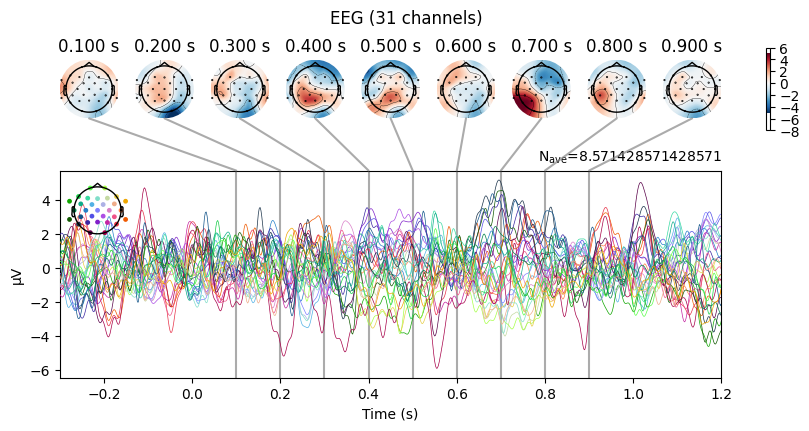

In [10]:
mne.combine_evoked([ grand_averages['go/correct/on-task/very immersed'], grand_averages['go/correct/spontaneous/very immersed']], weights=[1,-1]).plot_joint([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]);

# CLuster Analysis

In [213]:
on_task = 'go/correct/on-task'
spontaneous = 'go/correct/spontaneous'

evokeds_on_task = participant_evokeds[on_task]
evokeds_spontaneous = participant_evokeds[spontaneous]

# Assuming each evoked has data of shape (n_channels, n_times)
data_ontask = np.array([evk.data for evk in evokeds_on_task])  # Shape: (n_subjects, n_channels, n_times)
data_spontaneous = np.array([evk.data for evk in evokeds_spontaneous])  # Shape: (n_subjects, n_channels, n_times)

central_roi = ['FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2']

# Get indices of the ROI channels
picks = mne.pick_channels(evokeds_on_task[0].info['ch_names'], central_roi)

# Extract data for the selected channels and transpose to (n_subjects, n_times, n_channels)
X_condition1 = data_ontask[:, picks, :].transpose(0, 2, 1)
X_condition2 = data_spontaneous[:, picks, :].transpose(0, 2, 1)

# Combine data into a list
X = [X_condition1, X_condition2]  # Each element is (n_subjects, n_times, n_channels)



In [218]:
# Set the number of permutations
n_permutations = 1000

# Run the test
T_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
    X,
    n_permutations=n_permutations,
    threshold=None,  # Automatically set the threshold
    tail=0,          # Two-tailed test
    n_jobs=1         # Number of parallel jobs (adjust as needed)
)


# Define significance level
alpha = 0.05

# Find clusters with p-values below the significance level
significant_cluster_indices = np.where(cluster_p_values < alpha)[0]


Using a threshold of 4.195972
stat_fun(H1): min=3.2022497786544693e-08 max=7.604009633870106
Running initial clustering …
Found 16 clusters


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_17076\3973929352.py:5: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
100%|██████████| Permuting : 999/999 [00:00<00:00, 1285.29it/s]


In [219]:
import matplotlib.pyplot as plt

times = evokeds_on_task[0].times
ch_names = [evokeds_on_task[0].info['ch_names'][i] for i in picks]

if significant_cluster_indices.size > 0:
    for idx in significant_cluster_indices:
        # Get the cluster
        cluster = clusters[idx]
        time_inds, chan_inds = np.squeeze(cluster)

        # Get cluster data
        T_cluster = T_obs[time_inds, chan_inds]

        # Plot the cluster
        plt.figure()
        plt.title(f"Significant Cluster {idx} (p = {cluster_p_values[idx]:.3f})")
        plt.imshow(T_cluster.T, aspect='auto', origin='lower',
                   extent=[times[time_inds.start], times[time_inds.stop - 1], 0, len(chan_inds)])
        plt.colorbar(label='T-value')
        plt.xlabel('Time (s)')
        plt.ylabel('Channels')
        plt.yticks(np.arange(len(chan_inds)), [ch_names[i] for i in chan_inds])
        plt.show()
else:
    print("No significant clusters found.")


No significant clusters found.


# Immersion LMM model

In [8]:
conditions_of_interest = [
    'go/correct/on-task/a little immersed',
    'go/correct/spontaneous/a little immersed',
    'go/correct/on-task/somewhat immersed',
    'go/correct/spontaneous/somewhat immersed',
    'go/correct/on-task/very immersed',
    'go/correct/spontaneous/very immersed',
    'go/correct/on-task/completely immersed',
    'go/correct/spontaneous/completely immersed',
]


In [9]:
def compute_participant_evokeds(
    subjects,
    sessions,
    tasks,
    data,
    conditions_of_interest,
    derivatives_folder,
    sfreq=500,
    desired_tmin=-0.3,
    desired_tmax=1.2,
):
    import os
    import mne
    import numpy as np

    # Initialize a dictionary to hold evokeds per participant per condition
    participant_evokeds = {}

    for subject in subjects:
        participant_evokeds[subject] = {condition: [] for condition in conditions_of_interest}

        for session in sessions:
            for task in tasks:
                evoked_fname = os.path.join(
                    derivatives_folder,
                    f"sub-{subject}",
                    f"ses-{session}",
                    data,
                    f"sub-{subject}_ses-{session}_task-{task}_evokeds-ave.fif",
                )

                if not os.path.exists(evoked_fname):
                    continue

                try:
                    evokeds = mne.read_evokeds(evoked_fname)
                except Exception as e:
                    print(
                        f"Could not read evoked file for subject {subject}, session {session}, task {task}: {e}"
                    )
                    continue

                for evoked in evokeds:
                    evoked.resample(sfreq, npad="auto")
                    current_tmin = evoked.times[0]
                    if current_tmin != desired_tmin:
                        evoked.shift_time(desired_tmin - current_tmin, relative=True)
                    evoked.crop(tmin=desired_tmin, tmax=desired_tmax)

                    evoked_components = evoked.comment.replace(' × ', '/').split('/')

                    for condition in conditions_of_interest:
                        condition_components = condition.split('/')
                        if all(comp in evoked_components for comp in condition_components):
                            participant_evokeds[subject][condition].append(evoked)

    return participant_evokeds


In [78]:
# Get the current working directory
cwd = os.getcwd()

# Assuming the script is run from within the repository
repo = Repo(os.getcwd(), search_parent_directories=True)
repo_root = repo.git.rev_parse("--show-toplevel")

# Defining the paths for saving results and raw data
derivatives_folder = os.path.join(repo_root, "derivatives")
# bids_dir = os.path.join(derivatives_folder, f"sub-{subject}", f"ses-{session}", "eeg")

# Collect data
data_list = []

subjects = [str(i) if i > 9 else "0"+str(i) for i in range(1, 25)]
sessions = ["a", "b"]
tasks = ['sartvisual']
data = "eeg"

participant_evokeds = compute_participant_evokeds(
    subjects=subjects,
    sessions=sessions,
    tasks=tasks,
    data=data,
    conditions_of_interest=conditions_of_interest,
    derivatives_folder=derivatives_folder,
    sfreq=500,
    desired_tmin=-0.3,
    desired_tmax=1.2,
)

# Define time window (e.g., 300-500 ms)
tmin, tmax = 0.050, 0.200

# Define the channels of interest (ROI)
central_roi = ['FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2']


for subject in subjects:
    for condition in conditions_of_interest:
        evokeds = participant_evokeds.get(subject, {}).get(condition, [])
        if not evokeds:
            continue  # Skip if no evokeds for this condition

        # Combine evokeds for this subject and condition
        combined_evoked = mne.combine_evoked(evokeds, weights='equal')

        # Get picks for ROI
        picks = mne.pick_channels(combined_evoked.info['ch_names'], central_roi)

        # Get time indices for the specified time window
        times = combined_evoked.times
        time_mask = (times >= tmin) & (times <= tmax)

        # Extract data and compute mean amplitude
        data = combined_evoked.data[picks][:, time_mask].mean()

        # Extract immersion level (ordinal variable)
        # Assuming the last component of the condition string is the immersion level
        immersion_level = condition.split('/')[-1]
        # Map immersion level to numerical values
        immersion_mapping = {
            'a little immersed': 1,
            'somewhat immersed': 2,
            'very immersed': 3,
            'completely immersed': 4
        }
        immersion_value = immersion_mapping.get(immersion_level, np.nan)

        # Extract task status ('on-task' or 'spontaneous')
        task_status = 'on-task' if 'on-task' in condition else 'spontaneous'

        # Append data to the list
        data_list.append({
            'participant': subject,
            'condition': task_status,
            'immersion': immersion_value,
            'mean_amplitude': data,
        })


Reading C:\Users\nicolas.bruno\Documents\GitHub\wandering-mind\derivatives\sub-03\ses-b\eeg\sub-03_ses-b_task-sartvisual_evokeds-ave.fif ...
    Found the data of interest:
        t =    -300.00 ...    1199.98 ms (0.50 × go/correct/segment-6/1,26/on-task/somewhat confident/somewhat immersed + 0.50 × go/correct/segment-6/3,24/on-task/somewhat confident/somewhat immersed)
        0 CTF compensation matrices available
        nave = 2 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.3, 0] s)
    Found the data of interest:
        t =    -300.00 ...    1199.98 ms (0.33 × go/correct/segment-8/2,16/on-task/very confident/somewhat immersed + 0.33 × go/correct/segment-8/4,14/on-task/very confident/somewhat immersed + 0.33 × go/correct/segment-8/5,13/on-task/very confident/somewhat immersed)
        0 CTF compensation matrices available
        nave = 3 - aspect type = 100
No projecto

In [79]:
# Convert data list to DataFrame
dfp1 = pd.DataFrame(data_list)

# Display the DataFrame
print(dfp1.head())


# Compute Q1, Q3, and IQR for 'mean_amplitude'
Q1 = dfp1['mean_amplitude'].quantile(0.25)
Q3 = dfp1['mean_amplitude'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the bounds
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Filter out the outliers
df_filtered = dfp1[(dfp1['mean_amplitude'] >= lower_bound) & (dfp1['mean_amplitude'] <= upper_bound)]


  participant    condition  immersion  mean_amplitude
0          03      on-task          2   -2.944110e-05
1          03      on-task          3   -1.525224e-05
2          03  spontaneous          3   -1.111653e-05
3          03  spontaneous          4   -1.548628e-05
4          05      on-task          1    3.788361e-07


In [80]:
import statsmodels.formula.api as smf
# Convert 'participant' to categorical
df_filtered['participant'] = df_filtered['participant'].astype('category')

# Fit the LMM
model = smf.mixedlm(
    "mean_amplitude ~ condition * immersion",
    df_filtered,
    groups=df_filtered["participant"],
    re_formula="~condition"
)
result = model.fit()


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_28868\999553571.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning:

Retrying MixedLM optimization with lbfgs

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mn

In [81]:
print(result.summary())


                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       mean_amplitude
No. Observations:        74            Method:                   REML          
No. Groups:              16            Scale:                    0.0000        
Min. group size:         3             Log-Likelihood:           868.4345      
Max. group size:         8             Converged:                No            
Mean group size:         4.6                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            -0.000    0.000 -0.642 0.521 -0.000  0.000
condition[T.spontaneous]              0.000    0.000  1.112 0.266 -0.000  0.000
immersion                            -0.000    0.000 -0.056 0

In [89]:
# Group the data and calculate mean and standard error
grouped = dfp1.groupby(['immersion', 'condition']).agg(
    mean_amplitude=('mean_amplitude', 'mean'),
    sem=('mean_amplitude', 'sem')
).reset_index()

# Define marker symbols and colors
symbol_map = {'on-task': 'circle', 'spontaneous': 'square'}
color_map = {'on-task': '#F6956A', 'spontaneous': '#89A58F'}

# Create the plot
fig = px.line(
    grouped,
    x='immersion',
    y='mean_amplitude',
    color='condition',
    error_y='sem',
    symbol='condition',
    markers=True,
    color_discrete_map=color_map,
    symbol_map=symbol_map,
    labels={
        'immersion': 'Immersion Level',
        'mean_amplitude': 'Mean ERP Amplitude',
        'condition': 'Condition'
    },
    # title='Mean P1 Amplitude by Condition and Immersion Level'
)

# Adjust marker size and line width
fig.update_traces(marker=dict(size=10), line=dict(width=2))

# Update layout
fig.update_layout(
    width = 1000,
    height = 600,
    template = 'plotly_white',
    xaxis_title='Immersion Level',
    yaxis_title='Mean ERP Amplitude',
    legend_title='Condition',
    font=dict(size=30),
    xaxis=dict(
        categoryorder='array',
        categoryarray=['a little immersed', 'somewhat immersed', 'very immersed', 'completely immersed'],
        tickvals = (1,2,3, 4),
    )
)

# Rotate x-axis labels if necessary
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()

C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_28868\1832721740.py:4: FutureWarning:



The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.




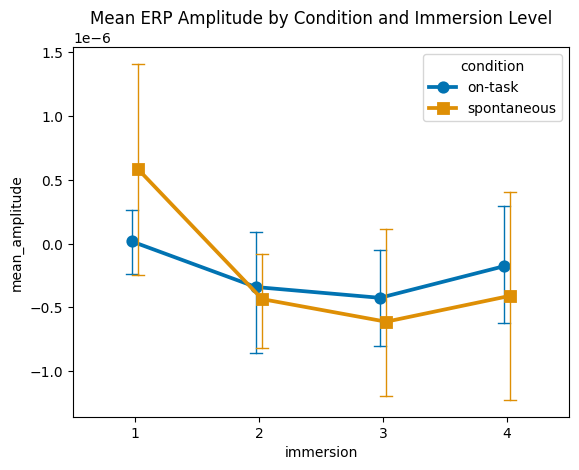

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(
    x='immersion', y='mean_amplitude', hue='condition',
    data=df_filtered, dodge=True, markers=['o', 's'], capsize=.1, errwidth=1, palette='colorblind'
)
plt.title('Mean ERP Amplitude by Condition and Immersion Level')
plt.show()


In [15]:
# Get the current working directory
cwd = os.getcwd()

# Assuming the script is run from within the repository
repo = Repo(os.getcwd(), search_parent_directories=True)
repo_root = repo.git.rev_parse("--show-toplevel")

# Defining the paths for saving results and raw data
derivatives_folder = os.path.join(repo_root, "derivatives")
# bids_dir = os.path.join(derivatives_folder, f"sub-{subject}", f"ses-{session}", "eeg")
# Collect data
data_list = []

subjects = [str(i) if i > 9 else "0"+str(i) for i in range(1, 25)]
sessions = ["a", "b"]
tasks = ['sartauditiva', 'sartvisual']
data = "eeg"

participant_evokeds = compute_participant_evokeds(
    subjects=subjects,
    sessions=sessions,
    tasks=tasks,
    data=data,
    conditions_of_interest=conditions_of_interest,
    derivatives_folder=derivatives_folder,
    sfreq=500,
    desired_tmin=-0.3,
    desired_tmax=1.2,
)

# Define time window (e.g., 300-500 ms)
tmin, tmax = 0.250, 0.450

# Define the channels of interest (ROI)
central_roi = ['FC1', 'FC2', 'C3', 'Cz', 'C4', 'CP1', 'CP2']


for subject in subjects:
    for condition in conditions_of_interest:
        evokeds = participant_evokeds.get(subject, {}).get(condition, [])
        if not evokeds:
            continue  # Skip if no evokeds for this condition

        # Combine evokeds for this subject and condition
        combined_evoked = mne.combine_evoked(evokeds, weights='equal')

        # Get picks for ROI
        picks = mne.pick_channels(combined_evoked.info['ch_names'], central_roi)

        # Get time indices for the specified time window
        times = combined_evoked.times
        time_mask = (times >= tmin) & (times <= tmax)

        # Extract data and compute mean amplitude
        data = combined_evoked.data[picks][:, time_mask].mean()

        # Extract immersion level (ordinal variable)
        # Assuming the last component of the condition string is the immersion level
        immersion_level = condition.split('/')[-1]
        # Map immersion level to numerical values
        immersion_mapping = {
            'a little immersed': 1,
            'somewhat immersed': 2,
            'very immersed': 3,
            'completely immersed': 4
        }
        immersion_value = immersion_mapping.get(immersion_level, np.nan)

        # Extract task status ('on-task' or 'spontaneous')
        task_status = 'on-task' if 'on-task' in condition else 'spontaneous'

        # Append data to the list
        data_list.append({
            'participant': subject,
            'condition': task_status,
            'immersion': immersion_value,
            'mean_amplitude': data,
        })


Reading C:\Users\nicolas.bruno\Documents\GitHub\wandering-mind\derivatives\sub-02\ses-a\eeg\sub-02_ses-a_task-sartauditiva_evokeds-ave.fif ...
    Found the data of interest:
        t =    -300.00 ...    1199.98 ms (0.33 × go/correct/segment-1/2,16/on-task/very confident/very immersed + 0.33 × go/correct/segment-1/3,15/on-task/very confident/very immersed + 0.33 × go/correct/segment-1/4,14/on-task/very confident/very immersed)
        0 CTF compensation matrices available
        nave = 3 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.3, 0] s)
    Found the data of interest:
        t =    -300.00 ...    1199.98 ms (0.25 × go/correct/segment-0/4,32/on-task/completely confident/very immersed + 0.25 × go/correct/segment-0/5,31/on-task/completely confident/very immersed + 0.25 × go/correct/segment-6/3,24/on-task/completely confident/very immersed + 0.25 × go/correct/segment-6/4

In [33]:
# Convert data list to DataFrame
dfp3 = pd.DataFrame(data_list)

# Display the DataFrame
print(dfp3.head())

# Compute Q1, Q3, and IQR for 'mean_amplitude'
Q1 = dfp3['mean_amplitude'].quantile(0.25)
Q3 = dfp3['mean_amplitude'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the bounds
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Filter out the outliers
df_filtered = dfp3[(dfp3['mean_amplitude'] >= lower_bound) & (dfp3['mean_amplitude'] <= upper_bound)]




  participant    condition  immersion  mean_amplitude
0          02      on-task          2       -0.000008
1          02      on-task          3       -0.000005
2          02  spontaneous          3        0.000012
3          02      on-task          4        0.000001
4          02  spontaneous          4       -0.000010


In [91]:
import statsmodels.formula.api as smf
# Convert 'participant' to categorical
dfp3['participant'] = dfp3['participant'].astype('category')

# Fit the LMM
model = smf.mixedlm(
    "mean_amplitude ~ condition * immersion",
    dfp3,
    groups=dfp3["participant"],
    re_formula="~condition"
)
result = model.fit()


c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning:

Retrying MixedLM optimization with lbfgs

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning:

The Hessian matrix at the estimated parameter values is not positive definite.



In [92]:
print(result.summary())


                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       mean_amplitude
No. Observations:        99            Method:                   REML          
No. Groups:              18            Scale:                    0.0000        
Min. group size:         4             Log-Likelihood:           1048.6286     
Max. group size:         8             Converged:                Yes           
Mean group size:         5.5                                                   
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            -0.000    0.000 -1.805 0.071 -0.000  0.000
condition[T.spontaneous]              0.000    0.000  1.268 0.205 -0.000  0.000
immersion                             0.000    0.000  2.318 0

In [87]:
# Group the data and calculate mean and standard error
grouped = dfp3.groupby(['immersion', 'condition']).agg(
    mean_amplitude=('mean_amplitude', 'mean'),
    sem=('mean_amplitude', 'sem')
).reset_index()

# Define marker symbols and colors
symbol_map = {'on-task': 'circle', 'spontaneous': 'square'}
color_map = {'on-task': '#F6956A', 'spontaneous': '#89A58F'}

# Create the plot
fig = px.line(
    grouped,
    x='immersion',
    y='mean_amplitude',
    color='condition',
    error_y='sem',
    symbol='condition',
    markers=True,
    color_discrete_map=color_map,
    symbol_map=symbol_map,
    labels={
        'immersion': 'Immersion Level',
        'mean_amplitude': 'Mean ERP Amplitude',
        'condition': 'Condition'
    },
    # title='Mean P3 Amplitude by Condition and Immersion Level'
)

# Adjust marker size and line width
fig.update_traces(marker=dict(size=10), line=dict(width=2))

# Update layout
fig.update_layout(
    width = 1000,
    height = 600,
    template = 'plotly_white',
    xaxis_title='Immersion Level',
    yaxis_title='Mean ERP Amplitude',
    legend_title='Condition',
    font=dict(size=30),
    xaxis=dict(
        categoryorder='array',
        categoryarray=['a little immersed', 'somewhat immersed', 'very immersed', 'completely immersed'],
        tickvals = (1,2,3, 4),
    )
)
# Rotate x-axis labels if necessary
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()

ValueError: RGBA sequence should have length 3 or 4

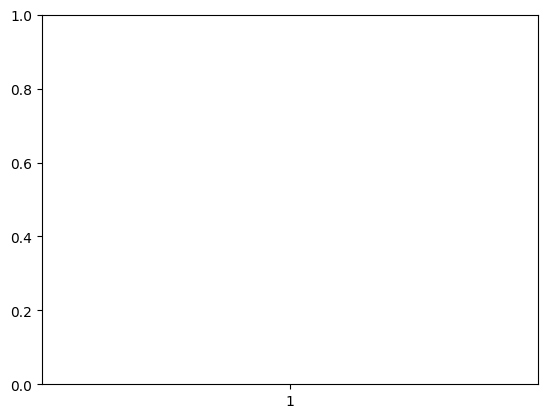

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(
    x='immersion', y='mean_amplitude', hue='condition',
    data=dfp3, dodge=True, markers=['o', 's'], capsize=.1, errwidth=1,color = ['#F6956A', '#89A58F'],)

plt.title('Mean ERP Amplitude by Condition and Immersion Level')
plt.show()


In [20]:
import plotly.express as px

fig = px.violin(
    dfp3,
    x='immersion',
    y='mean_amplitude',
    color='condition',
    box=True,                   # Add box plot inside the violin
    points='all',               # Show all data points
    hover_data=dfp3.columns,    # Include all columns in the hover tooltip
    category_orders={
        'immersion': ['a little immersed', 'somewhat immersed', 'very immersed', 'completely immersed']
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Update layout
fig.update_layout(
    title='Mean ERP Amplitude by Condition and Immersion Level',
    xaxis_title='Immersion Level',
    yaxis_title='Mean ERP Amplitude',
    legend_title='Condition',
    font=dict(size=12)
)

# Rotate x-axis labels if needed
fig.update_xaxes(tickangle=45)

# Show the interactive plot
fig.show()


In [42]:
import pandas as pd
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)


# Compute Q1, Q3, and IQR for 'mean_amplitude'
Q1 = dfp3['mean_amplitude'].quantile(0.25)
Q3 = dfp3['mean_amplitude'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the bounds
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Filter out the outliers
df_filtered = dfp3[(dfp3['mean_amplitude'] >= lower_bound) & (dfp3['mean_amplitude'] <= upper_bound)]


# Calculate mean amplitudes
mean_data = df_filtered.groupby(['immersion', 'condition'], as_index=False)['mean_amplitude'].mean()


colors = {'on-task':'#F6956A', 'spontaneous':'#89A58F',}


# Create the boxplot
fig = px.box(
    df_filtered,
    x='immersion',
    y='mean_amplitude',
    color='condition',
    category_orders={
        'immersion': ['a little immersed', 'somewhat immersed', 'very immersed', 'completely immersed']
    },
    points=False,   # Show all data points
    color_discrete_map=colors
)

# Add line plots for the means
for condition in dfp3['condition'].unique():
    condition_data = mean_data[mean_data['condition'] == condition]
    fig.add_trace(go.Scatter(
        x=condition_data['immersion'],
        y=condition_data['mean_amplitude'],
        mode='lines+markers',
        name=f'{condition} Mean',
        line=dict(color=colors[condition], width=2),
        marker=dict(symbol='circle', size=8),
        showlegend=True
    ))

# Update layout
fig.update_layout(
    title='Mean ERP Amplitude by Condition and Immersion Level',
    xaxis_title='Immersion Level',
    yaxis_title='Mean ERP Amplitude',
    xaxis=dict(
        categoryorder='array',
        categoryarray=['a little immersed', 'somewhat immersed', 'very immersed', 'completely immersed']
    ),
    legend_title='Condition',
    font=dict(size=12)
)

# Rotate x-axis labels if needed
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()
